# Week 5 – Model Evaluation & Deployment Preparation

## Task 1: Evaluate a Classification Model



In [1]:
# importing libraries needed for task 1
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [2]:
# loading the breast cancer wisconsin dataset
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Shape of features:", X.shape)
print("Target classes:", data.target_names)
X.head()


Shape of features: (569, 30)
Target classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# quick check for missing values / class balance before training
print("Missing values:\n", X.isnull().sum().sum())
print("\nClass distribution:")
print(y.value_counts())


Missing values:
 0

Class distribution:
target
1    357
0    212
Name: count, dtype: int64


In [4]:
# train/test split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 455
Testing samples: 114


In [5]:

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
print("Model trained successfully.")


Model trained successfully.


In [6]:
# 1) Accuracy Score
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc:.4f} ({acc*100:.2f}%)")


Accuracy Score: 0.9561 (95.61%)


Confusion Matrix:
 [[39  3]
 [ 2 70]]


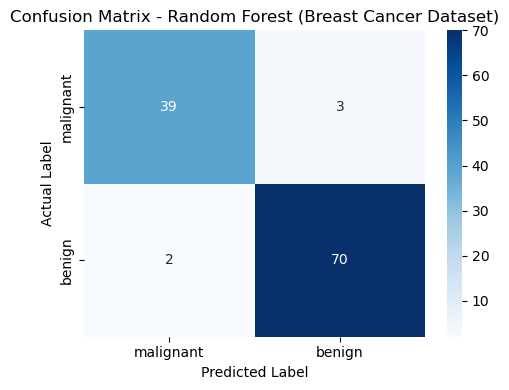

In [7]:
# 2) Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest (Breast Cancer Dataset)")
plt.tight_layout()
plt.show()


In [8]:
# 3) Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))


Classification Report:

              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



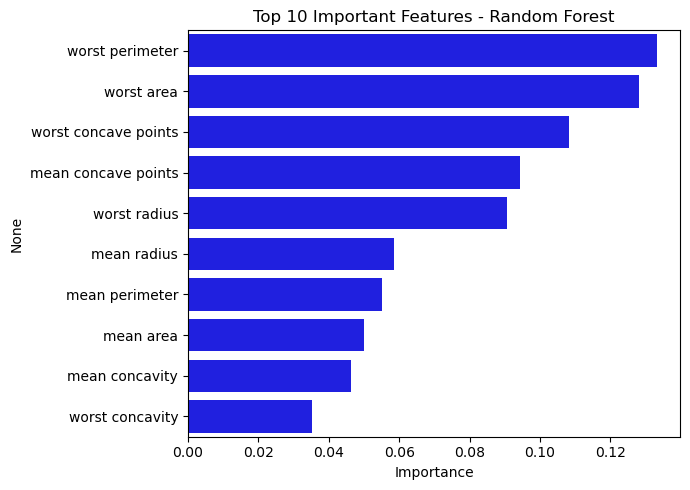

In [9]:
# in which features the model relied on most
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(7, 5))
sns.barplot(x=top_features.values, y=top_features.index, color="blue")
plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


**Observation:** The Random Forest model performs well on the Breast Cancer Wisconsin dataset,
achieving high accuracy with very few misclassifications. Features like `worst radius`,
`worst perimeter` and `worst concave points` contribute the most to the model's decisions,
which lines up with medical intuition (tumor size/shape irregularities are strong cancer indicators).


## Task 2: Save and Load a Machine Learning Model


In [10]:
# imports for task 2
import joblib
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier


In [11]:
# loading the iris dataset
iris = load_iris()
X_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
y_iris = pd.Series(iris.target, name="species")

print("Shape:", X_iris.shape)
print("Classes:", iris.target_names)
X_iris.head()


Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [12]:
# split into train/test sets
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=42, stratify=y_iris
)

print("Training samples:", X_train_i.shape[0])
print("Testing samples:", X_test_i.shape[0])


Training samples: 120
Testing samples: 30


In [13]:
# training a Decision Tree Classifier
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train_i, y_train_i)

train_acc = dt_model.score(X_train_i, y_train_i)
test_acc = dt_model.score(X_test_i, y_test_i)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")


Training Accuracy: 0.9917
Testing Accuracy: 0.9333


In [14]:
# saving the trained model to disk using joblib
model_filename = "iris_decision_tree_model.joblib"
joblib.dump(dt_model, model_filename)
print(f"Model saved as '{model_filename}'")


Model saved as 'iris_decision_tree_model.joblib'


In [15]:
# simulating a fresh application 
loaded_model = joblib.load(model_filename)
print("Model loaded successfully from disk.")
print(type(loaded_model))


Model loaded successfully from disk.
<class 'sklearn.tree._classes.DecisionTreeClassifier'>


In [16]:
# using the loaded model to make predictions on the test set
loaded_preds = loaded_model.predict(X_test_i)

loaded_acc = accuracy_score(y_test_i, loaded_preds)
print(f"Accuracy of loaded model on test set: {loaded_acc:.4f}")

# sanity check: predictions from loaded model should match the original model
original_preds = dt_model.predict(X_test_i)
print("Predictions match original model:", np.array_equal(loaded_preds, original_preds))


Accuracy of loaded model on test set: 0.9333
Predictions match original model: True


In [17]:

sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)
predicted_class = loaded_model.predict(sample)[0]
print("Sample measurements:", sample.values.tolist())
print("Predicted species:", iris.target_names[predicted_class])


Sample measurements: [[5.1, 3.5, 1.4, 0.2]]
Predicted species: setosa


**Observation:** Saving the model with Joblib means the Decision Tree does not need to be
retrained every time the application restarts — it can simply be loaded from the
`.joblib` file, which is much faster and is exactly how a real deployed ML service would
work in production.


---
## Summary

| Task | Dataset | Model | Result |
|------|---------|-------|--------|
| Task 1 | Breast Cancer Wisconsin | Random Forest Classifier | High accuracy, evaluated with accuracy score, confusion matrix & classification report |
| Task 2 | Iris | Decision Tree Classifier | Model trained, saved as `.joblib`, reloaded, and verified to give identical predictions |

Both models were trained, evaluated and (for Task 2) persisted to disk as required by the
Week 5 deliverables. Deliverables to push to GitHub: this notebook, the saved
`iris_decision_tree_model.joblib` file, and output screenshots.
